# Projet Python pour la data science

## Introduction

## 1. Import et installation des packages nécessaires

On commence par importer et installer les packages nécessaires au projet. Les packages à installer sont recensés dans le fichier requirements.txt.

In [1]:
!pip install -q -r requirements.txt

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import geopandas as gpd
import matplotlib.colors as mcolors

In [3]:
import fonctions

## 2. Récupération des données

Ce projet mobilise deux sources de données complémentaires :

- **Les données Drees (ER 1243)** : taux de prévalence et d'incidence de maladies chroniques ventilés par variables socio-démographiques, disponibles sur data.gouv.fr
- **Les données Insee (Filosofi)** : indicateurs socio-économiques par région (taux de pauvreté, revenu médian), également disponibles sur data.gouv.fr

Les deux sources sont chargées directement via l'API de data.gouv.fr, ce qui garantit la reproductibilité du projet.

### 2.1 Utilisation de l'API data.gouv.fr

Plutôt que de télécharger manuellement les fichiers, nous utilisons l'API de data.gouv.fr pour charger les données directement dans le notebook.

L'API permet d'interroger les métadonnées d'un jeu de données via son identifiant, et d'en récupérer les ressources (fichiers) associées.

La structure d'une requête est la suivante :
`GET https://www.data.gouv.fr/api/1/datasets/{dataset_id}/`

On va maintenant explorer les métadonnées DREES via l'API afin de voir tous les fichiers disponibles ainsi que leurs URL et de mieux comprendre les données que l'on va charger.

In [4]:
# Identifiant du dataset DREES sur data.gouv.fr
DATASET_ID = "inegalites-sociales-face-aux-maladies-chroniques-er-1243"

# Requête sur l'API pour récupérer les métadonnées
response = requests.get(f"https://www.data.gouv.fr/api/1/datasets/{DATASET_ID}/")
metadata = response.json()

# Affichage des ressources disponibles dans ce dataset
print(f"Titre : {metadata['title']}")
print(f"\nRessources disponibles ({len(metadata['resources'])}) :")
for r in metadata['resources']:
    print(f"  - {r['title']} | format : {r['format']} | url : {r['url']}")

Titre : Inégalités sociales face aux maladies chroniques (ER 1243)

Ressources disponibles (4) :
  - er_inegalites_maladies_chroniques.csv | format : csv | url : https://data.drees.solidarites-sante.gouv.fr/api/explore/v2.1/catalog/datasets/er_inegalites_maladies_chroniques/exports/csv?use_labels=true
  - er_inegalites_maladies_chroniques.json | format : json | url : https://data.drees.solidarites-sante.gouv.fr/api/explore/v2.1/catalog/datasets/er_inegalites_maladies_chroniques/exports/json
  - ex_analyse_maladies_chroniques.R | format : octet-stream | url : https://data.drees.solidarites-sante.gouv.fr/api/v2/catalog/datasets/er_inegalites_maladies_chroniques/alternative_exports/ex_analyse_maladies_chroniques_r
  - libelles_er1243.xlsx | format : vnd.openxmlformats-officedocument.spreadsheetml.sheet | url : https://data.drees.solidarites-sante.gouv.fr/api/v2/catalog/datasets/er_inegalites_maladies_chroniques/alternative_exports/libelles_er1243_xlsx


Maintenant, il faut extraire les URL pour pouvoir ensuite charger les données.

In [5]:
# Extraction des URLs par format
urls = {r['format']: r['url'] for r in metadata['resources']}

URL_CSV    = urls.get('csv')
URL_LABELS = urls.get('vnd.openxmlformats-officedocument.spreadsheetml.sheet')

print(f"URL CSV    : {URL_CSV}")
print(f"URL LABELS : {URL_LABELS}")

URL CSV    : https://data.drees.solidarites-sante.gouv.fr/api/explore/v2.1/catalog/datasets/er_inegalites_maladies_chroniques/exports/csv?use_labels=true
URL LABELS : https://data.drees.solidarites-sante.gouv.fr/api/v2/catalog/datasets/er_inegalites_maladies_chroniques/alternative_exports/libelles_er1243_xlsx


### 2.2 Chargement du dataset principal Drees

In [6]:
print("Chargement du dataset Drees...")
df = pd.read_csv(URL_CSV, sep=";", low_memory=False)

print(f"✓ Dataset chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head()

Chargement du dataset Drees...
✓ Dataset chargé : 46176 lignes × 20 colonnes


,type,varTaux,varTauxLib,I_cat,cat,catLib,varPartition,valPartition,varGroupage,valGroupage,varPoids,poids1,poidsTot,txNonStand,txStandDir,txStandDirModBB,txStandDirModBH,txStandIndir,txStandIndirModBB,txStandIndirModBH
0,incidence,TOP_CVIC_CHR,Insuffisance cardiaque chronique,0,SUP_CV_CAT,Maladies cardioneurovasculaires,FISC_REG_S,28,NaN,NaN,POIDS_FIDELI_S,30116.961505,6.302392e+06,0.004779,0.004779,0.004521,0.005037,0.004779,0.004521,0.005037
1,incidence,TOP_PRETARD_IND,Déficience mentale,0,SUP_PSYPAT_CAT,Maladies psychiatriques,FISC_REG_S,28,NaN,NaN,POIDS_FIDELI_S,1309.430271,6.349002e+06,0.000206,0.000206,0.000150,0.000263,0.000206,0.000150,0.000263
2,incidence,TOP_RTRANS_CHR,Suivi de transplantation rénale,0,SUP_RIRCT_CAT,Insuffisance rénale chronique terminale,FISC_REG_S,28,FISC_NIVVIEM_E2015_S_moy_10,1,POIDS_FIDELI_S,0.000000,5.294220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,incidence,TOP_CVTRRYC_IND,Troubles du rythme ou de la conduction cardiaque,0,SUP_CV_CAT,Maladies cardioneurovasculaires,FISC_REG_S,28,FISC_NIVVIEM_E2015_S_moy_10,2,POIDS_FIDELI_S,6959.005587,6.266976e+05,0.011104,0.011745,0.010400,0.013090,0.011888,0.010576,0.013201
4,incidence,TOP_IRHEMOP_IND,Hémophilie ou troubles de l'hémostase graves,0,SUP_INFRARVIH_CAT,Maladies inflammatoires ou rares ou VIH ou SIDA,FISC_REG_S,28,FISC_NIVVIEM_E2015_S_moy_10,2,POIDS_FIDELI_S,92.865604,6.438119e+05,0.000144,0.000147,-0.000005,0.000300,0.000154,-0.000004,0.000312


### 2.3 Chargement du fichier de libellés

Le fichier `libelles_er1243.xlsx` fourni par la DREES permet de décoder les codes des modalités présents dans les colonnes `valGroupage` et `valPartition`.
Par exemple, le code `"1"` pour le décile de revenu correspond à "20% les plus modestes".

In [7]:
print("Chargement du fichier de libellés...")
response_labels = requests.get(URL_LABELS)
labels = pd.read_excel(BytesIO(response_labels.content))

print(f"✓ Libellés chargés : {labels.shape[0]} lignes × {labels.shape[1]} colonnes")
labels.head(10)

Chargement du fichier de libellés...
✓ Libellés chargés : 54 lignes × 3 colonnes


,var,moda,moda_lib
0,EAR_DIPLR_S,NaN,NaN
1,EAR_DIPLR_S,1,Pas de diplôme
2,EAR_DIPLR_S,2,BEP/CAP
3,EAR_DIPLR_S,3,Baccalauréat
4,EAR_DIPLR_S,4,Enseignement supérieur
5,EAR_GS_S,1,Agriculteurs exploitants
6,EAR_GS_S,2,"Artisans, commerçants, chefs d'entreprise"
7,EAR_GS_S,3,Cadres et professions intellectuelles supérieures
8,EAR_GS_S,4,Professions intermédiaires
9,EAR_GS_S,5,Employés


### 2.4 Chargement des données Insee — Filosofi (revenus et pauvreté par région)

Pour contextualiser les disparités régionales observées dans les données DREES, nous enrichissons le dataset avec des indicateurs socio-économiques régionaux issus du dispositif **Filosofi** (Fichier localisé social et fiscal) de l'INSEE, également disponibles sur data.gouv.fr.

Ces données fournissent notamment le **taux de pauvreté** et le **revenu médian par unité de consommation** pour chaque région, qui sont les indicateurs les plus directement comparables avec les ventilations par décile de niveau de vie du dataset DREES.

Nous allons récupérer ces données via l'API data.gouv.fr.

In [8]:
# Identifiant du dataset Filosofi sur data.gouv.fr
DATASET_INSEE_ID = "67f5bb0403325228295b7e85"

response_insee = requests.get(
    f"https://www.data.gouv.fr/api/1/datasets/{DATASET_INSEE_ID}/"
)

if response_insee.status_code != 200:
    print("Erreur API :", response_insee.status_code)

metadata_insee = response_insee.json()

print(f"Titre : {metadata_insee['title']}")
print(f"\nRessources disponibles ({len(metadata_insee['resources'])}) :")
for r in metadata_insee['resources']:
    print(f"  - {r['title']} | format : {r['format']}")

Titre : Carroyage Filosofi (revenus, pauvreté et niveau de vie en 2019)

Ressources disponibles (4) :
  - se_filosofi_200_s.csv | format : csv
  - se_filosofi_200_s.json | format : json
  - se_filosofi_200_s.geojson | format : json
  - se_filosofi_200_s.zip | format : zip


Chargons maintenant le fichier regional Filosofi.

In [9]:
url_filosofi = next(
    (
        r['url']
        for r in metadata_insee['resources']
        if r.get('format') == 'csv'
    ),
    None
)

print(f"URL ciblée : {url_filosofi}")

URL ciblée : https://datahub.bordeaux-metropole.fr/api/explore/v2.1/catalog/datasets/se_filosofi_200_s/exports/csv?use_labels=true


In [10]:
df_insee = pd.read_csv(url_filosofi, sep=";", low_memory=False)

print(f"✓ Données INSEE chargées : {df_insee.shape[0]} lignes × {df_insee.shape[1]} colonnes")
df_insee.head()

✓ Données INSEE chargées : 6751 lignes × 37 colonnes


,Geo Point,Geo Shape,gid,geom_err,ident,insee,val_approchee,nb_ind,nb_men,nb_men_pauv,...,nb_ind_11_17,nb_ind_18_24,nb_ind_25_39,nb_ind_40_54,nb_ind_55_64,nb_ind_65_79,nb_ind_80p,nb_ind_nc,cdate,mdate
0,"44.91206070569204, -0.5100061272621179","{""coordinates"": [[[-0.5110917, 44.9110429], [-...",678178,NaN,CRS3035RES200mN2480600E3492600,33032,False,154.0,79.0,3.0,...,8.5,15.0,48.0,38.0,19.0,8.0,4.0,0.0,2024-06-25T08:41:03+00:00,2024-06-25T08:41:03+00:00
1,"44.913831082951546, -0.4924421659563439","{""coordinates"": [[[-0.4935281, 44.9128134], [-...",678183,NaN,CRS3035RES200mN2480600E3494000,33096,True,3.0,1.1,0.3,...,0.2,0.1,1.0,0.3,0.5,0.0,0.1,0.0,2024-06-25T08:41:03+00:00,2024-06-25T08:41:03+00:00
2,"44.88952493299521, -0.7486191660333198","{""coordinates"": [[[-0.7497001, 44.8885047], [-...",678764,NaN,CRS3035RES200mN2480800E3473600,33449,False,59.0,26.0,0.0,...,0.0,3.0,7.0,4.0,15.0,20.0,2.0,0.0,2024-06-25T08:41:03+00:00,2024-06-25T08:41:03+00:00
3,"44.91510820569247, -0.4977980272593909","{""coordinates"": [[[-0.4988839, 44.9140905], [-...",678794,NaN,CRS3035RES200mN2480800E3493600,33096,False,74.0,26.0,3.0,...,11.0,4.0,10.0,26.0,8.0,7.0,1.0,0.0,2024-06-25T08:41:03+00:00,2024-06-25T08:41:03+00:00
4,"44.916624105693145, -0.48274222725639315","{""coordinates"": [[[-0.4838284, 44.9156065], [-...",678799,NaN,CRS3035RES200mN2480800E3494800,"33003,33397",True,20.5,7.3,1.9,...,1.5,0.4,6.9,2.3,3.1,0.0,0.4,0.0,2024-06-25T08:41:03+00:00,2024-06-25T08:41:03+00:00


In [66]:
print(df_insee.columns)

Index(['Geo Point', 'Geo Shape', 'gid', 'geom_err', 'ident', 'insee',
       'val_approchee', 'nb_ind', 'nb_men', 'nb_men_pauv', 'nb_men_1ind',
       'nb_men_5ind', 'nb_men_prop', 'nb_men_monop', 'nv_ind', 'surf_log',
       'nb_men_hab_col', 'nb_men_hab_ind', 'nb_log_av45', 'nb_log_45_70',
       'nb_log_70_90', 'nb_log_ap90', 'nb_log_nc', 'nb_log_soc', 'nb_ind_0_3',
       'nb_ind_4_5', 'nb_ind_6_10', 'nb_ind_11_17', 'nb_ind_18_24',
       'nb_ind_25_39', 'nb_ind_40_54', 'nb_ind_55_64', 'nb_ind_65_79',
       'nb_ind_80p', 'nb_ind_nc', 'cdate', 'mdate'],
      dtype='object')


### 2.5 Vérification du chargement

Avant tout nettoyage, on vérifie que les trois sources sont bien chargées et cohérentes.

In [11]:
sources = {
    "DREES - Maladies chroniques" : df,
    "DREES - Libellés"           : labels,
    "INSEE - Filosofi régions"   : df_insee,
}

for nom, dataframe in sources.items():
    print(f"{nom}")
    print(f"  → {dataframe.shape[0]} lignes × {dataframe.shape[1]} colonnes")
    print(f"  → Valeurs manquantes : {dataframe.isnull().sum().sum()}")
    print()

DREES - Maladies chroniques
  → 46176 lignes × 20 colonnes
  → Valeurs manquantes : 10738

DREES - Libellés
  → 54 lignes × 3 colonnes
  → Valeurs manquantes : 2

INSEE - Filosofi régions
  → 6751 lignes × 37 colonnes
  → Valeurs manquantes : 6751



## 3. Exploration préalable des données

Avant tout nettoyage ou analyse, on explore la structure et le contenu des trois sources chargées afin de :
- comprendre l'organisation des données
- identifier les variables utiles pour répondre à la problématique
- repérer d'éventuels problèmes (valeurs manquantes, types incorrects, doublons)

### 3.1 Exploration du dataset DREES

Commençons par regarder la structure générale du dataset DREES (df). 

#### 3.1.1 Structure générale du dataset

On va dans un premier temps s'intéresser aux dimensions du dataset (nombre de lignes et colonnes) ainsi qu'au type des variables.

In [12]:
# Dimensions et types
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes\n")
print("Types des colonnes :")
print(df.dtypes)

Dimensions : 46176 lignes × 20 colonnes

Types des colonnes :
type                  object
varTaux               object
varTauxLib            object
I_cat                  int64
cat                   object
catLib                object
varPartition          object
valPartition          object
varGroupage           object
valGroupage           object
varPoids              object
poids1               float64
poidsTot             float64
txNonStand           float64
txStandDir           float64
txStandDirModBB      float64
txStandDirModBH      float64
txStandIndir         float64
txStandIndirModBB    float64
txStandIndirModBH    float64
dtype: object


In [13]:
n_numeriques = df.select_dtypes(include='number').shape[1]
n_categorielles = df.select_dtypes(include='object').shape[1]
print(f"Variables numériques : {n_numeriques}\n")
print(f"Variables catégorielles : {n_categorielles}\n")

Variables numériques : 10

Variables catégorielles : 10



In [14]:
print(f"Le contient {df.shape[0]} lignes (observations) et {df.shape[1]} colonnes (variables).")

print("\n--- Structure du jeu de données ---")
print(df.info())

print("\n--- Liste des noms de variables ---")
print(df.columns.tolist())

Le contient 46176 lignes (observations) et 20 colonnes (variables).

--- Structure du jeu de données ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46176 entries, 0 to 46175
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   type               46176 non-null  object 
 1   varTaux            46176 non-null  object 
 2   varTauxLib         46176 non-null  object 
 3   I_cat              46176 non-null  int64  
 4   cat                46176 non-null  object 
 5   catLib             46176 non-null  object 
 6   varPartition       43160 non-null  object 
 7   valPartition       43160 non-null  object 
 8   varGroupage        44408 non-null  object 
 9   valGroupage        44408 non-null  object 
 10  varPoids           46176 non-null  object 
 11  poids1             46172 non-null  float64
 12  poidsTot           46172 non-null  float64
 13  txNonStand         46172 non-null  float64
 14  txStandDir   

Nous possédons ainsi plus de 46000 obsevrations pour 20 variables dans notre base de données.

#### 3.1.2 Statistiques descriptives sur les variables numériques

Maintenant que l'on connait le type des colonnes, intéressons nous plus particulièrement aux variables numériques et vérifions notamment que les ordres de grandeur de ces variables sont cohérents avec ce qui est attendu (par exemple, un taux doit être compris entre 0 et 1).

In [15]:
# Statistiques descriptives des colonnes numériques
df.describe()

,I_cat,poids1,poidsTot,txNonStand,txStandDir,txStandDirModBB,txStandDirModBH,txStandIndir,txStandIndirModBB,txStandIndirModBH
count,46176.000000,4.617200e+04,4.617200e+04,46172.000000,46172.000000,46172.000000,46172.000000,45794.000000,45794.000000,45794.000000
mean,0.211538,4.084664e+04,3.306689e+06,0.015083,0.014951,0.013526,0.016377,0.014984,0.013608,0.016359
std,0.408404,1.788971e+05,5.607415e+06,0.037744,0.037236,0.035579,0.039294,0.037206,0.035653,0.039123
min,0.000000,0.000000e+00,4.365972e+02,0.000000,0.000000,-0.046276,0.000000,0.000000,-0.057530,0.000000
25%,0.000000,3.513649e+02,3.640001e+05,0.000570,0.000576,0.000209,0.000841,0.000598,0.000244,0.000869
50%,0.000000,2.614705e+03,9.753148e+05,0.002697,0.002720,0.001930,0.003485,0.002767,0.001986,0.003504
75%,0.000000,1.636898e+04,3.640875e+06,0.011545,0.011624,0.009733,0.013296,0.011734,0.009851,0.013414
max,1.000000,6.070514e+06,4.773171e+07,0.588601,0.588512,0.580976,0.678644,0.590223,0.580827,0.708820


#### 3.1.3 Valeurs manquantes

Maintenant il est temps de s'intéresser à un point essentiel dont il faudra tenir compte dans la suite de notre projet, les valeurs manquantes.

In [16]:
# Valeurs manquantes par colonne
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'nb_manquants': missing,
    'pct_manquants': missing_pct
}).query('nb_manquants > 0').sort_values('pct_manquants', ascending=False)

print(f"{len(missing_df)} colonnes contiennent des valeurs manquantes :\n")
print(missing_df)

13 colonnes contiennent des valeurs manquantes :

                   nb_manquants  pct_manquants
varPartition               3016           6.53
valPartition               3016           6.53
varGroupage                1768           3.83
valGroupage                1768           3.83
txStandIndirModBB           382           0.83
txStandIndir                382           0.83
txStandIndirModBH           382           0.83
poids1                        4           0.01
poidsTot                      4           0.01
txStandDirModBB               4           0.01
txStandDir                    4           0.01
txNonStand                    4           0.01
txStandDirModBH               4           0.01


#### 3.1.4 Variables d'intérêt

Le dataset est structuré autour de trois axes principaux :
- **`type`** : prévalence ou incidence
- **`varGroupage` / `valGroupage`** : la variable de ventilation et sa modalité (ex. décile de revenu, CSP, diplôme...)
- **`varPartition` / `valPartition`** : une éventuelle partition supplémentaire par région ou par sexe

Ces variables nous seront particulièrement utiles pour la suite.

In [17]:
# Valeurs uniques des variables de structure
print("=== type ===")
print(df['type'].value_counts())

print("\n=== varGroupage (variables de ventilation disponibles) ===")
print(df['varGroupage'].value_counts())

print("\n=== varPartition ===")
print(df['varPartition'].value_counts())

=== type ===
type
incidence     23088
prevalence    23088
Name: count, dtype: int64

=== varGroupage (variables de ventilation disponibles) ===
varGroupage
FISC_NIVVIEM_E2015_S_moy_10    20800
classeAge10                    16640
SEXE                            3536
EAR_GS_S                        2184
EAR_DIPLR_S                     1248
Name: count, dtype: int64

=== varPartition ===
varPartition
FISC_REG_S    37128
SEXE           6032
Name: count, dtype: int64


In [18]:
# Valeurs uniques des variables de structure
print("=== type ===")
print(df['type'].value_counts())

print("\n=== varGroupage (variables de ventilation disponibles) ===")
print(df['varGroupage'].value_counts())

print("\n=== varPartition ===")
print(df['varPartition'].value_counts())

=== type ===
type
incidence     23088
prevalence    23088
Name: count, dtype: int64

=== varGroupage (variables de ventilation disponibles) ===
varGroupage
FISC_NIVVIEM_E2015_S_moy_10    20800
classeAge10                    16640
SEXE                            3536
EAR_GS_S                        2184
EAR_DIPLR_S                     1248
Name: count, dtype: int64

=== varPartition ===
varPartition
FISC_REG_S    37128
SEXE           6032
Name: count, dtype: int64


In [19]:
# Nombre de maladies distinctes dans le dataset
print(f"Nombre de maladies/pathologies distinctes : {df['varTauxLib'].nunique()}")
print("\nListe des pathologies :")
print(df['varTauxLib'].unique())

Nombre de maladies/pathologies distinctes : 52

Liste des pathologies :
['Insuffisance cardiaque chronique' 'Déficience mentale'
 'Suivi de transplantation rénale'
 'Troubles du rythme ou de la conduction cardiaque'
 "Hémophilie ou troubles de l'hémostase graves"
 'Maladie coronaire chronique'
 'Maladies inflammatoires chroniques intestinales' 'Cancers'
 'Traitements antihypertenseurs'
 'Polyarthrite rhumatoïde et maladies apparentées' 'Épilepsie'
 'Traitements neuroleptiques'
 'Artériopathie oblitérante du membre inférieur' 'Syndrome coronaire aigu'
 'Maladies métaboliques héréditaires ou amylose' 'VIH ou SIDA'
 'Maladies psychiatriques' 'Maladie valvulaire'
 'Traitements hypolipémiants' 'Autres affections neurologiques'
 'Troubles addictifs' 'Maladies du foie ou du pancréas'
 'Insuffisance cardiaque aiguë' 'Insuffisance rénale chronique terminale'
 'Myopathie ou myasthénie' 'Maladie de Parkinson'
 "Traitements antidépresseurs ou régulateurs de l'humeur"
 'Troubles psychotiques' 'Trai

On examine la distribution du taux de prévalence standardisé direct (`txStandDir`) pour avoir une idée de l'ordre de grandeur des valeurs et repérer d'éventuelles valeurs aberrantes.

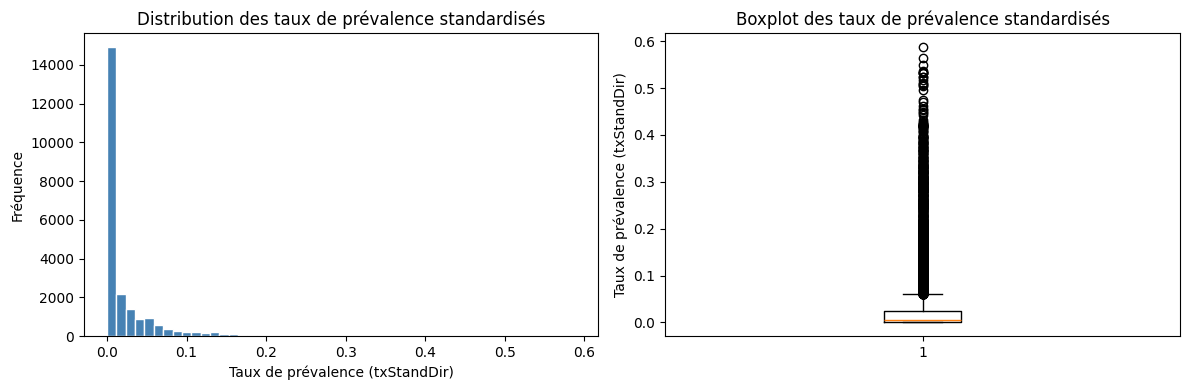


Min : 0.0000
Max : 0.5885
Médiane : 0.0049


In [20]:
prevalences = df[df['type'] == 'prevalence']['txStandDir'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme
axes[0].hist(prevalences, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Distribution des taux de prévalence standardisés")
axes[0].set_xlabel("Taux de prévalence (txStandDir)")
axes[0].set_ylabel("Fréquence")

# Boxplot
axes[1].boxplot(prevalences, vert=True)
axes[1].set_title("Boxplot des taux de prévalence standardisés")
axes[1].set_ylabel("Taux de prévalence (txStandDir)")

plt.tight_layout()
plt.show()

print(f"\nMin : {prevalences.min():.4f}")
print(f"Max : {prevalences.max():.4f}")
print(f"Médiane : {prevalences.median():.4f}")

### 3.2 Exploration du fichier de libellés

#### 3.2.1 Structure générale

On vérifie la structure du fichier de libellés afin de préparer la jointure avec le dataset principal.

In [21]:
# Dimensions et types
print(f"Dimensions : {labels.shape[0]} lignes × {labels.shape[1]} colonnes\n")
print("Types des colonnes :")
print(labels.dtypes)
labels.head(5)

Dimensions : 54 lignes × 3 colonnes

Types des colonnes :
var         object
moda        object
moda_lib    object
dtype: object


,var,moda,moda_lib
0,EAR_DIPLR_S,NaN,NaN
1,EAR_DIPLR_S,1,Pas de diplôme
2,EAR_DIPLR_S,2,BEP/CAP
3,EAR_DIPLR_S,3,Baccalauréat
4,EAR_DIPLR_S,4,Enseignement supérieur


In [22]:
n_numeriques_labels = labels.select_dtypes(include='number').shape[1]
n_categorielles_labels = labels.select_dtypes(include='object').shape[1]
print(f"Variables numériques : {n_numeriques_labels}\n")
print(f"Variables catégorielles : {n_categorielles_labels}\n")

Variables numériques : 0

Variables catégorielles : 3



#### 3.2.2 Toutes les modalités du datasat principal ont-elles un libellé ?

In [23]:
# Vérification : toutes les modalités du dataset principal ont-elles un libellé ?
modalites_drees = df['varGroupage'].unique()
modalites_labels = labels.iloc[:, 0].unique()  # à ajuster selon le nom de colonne réel

non_couverts = [m for m in modalites_drees if m not in modalites_labels]
print(f"Modalités sans libellé : {non_couverts}")

Modalités sans libellé : [nan]


#### 3.2.3 Valeurs manquantes

In [24]:
# Valeurs manquantes par colonne
missing_labels = labels.isnull().sum()
missing_pct_labels = (missing_labels / len(labels) * 100).round(2)

missing_labels = pd.DataFrame({
    'nb_manquants': missing_labels,
    'pct_manquants': missing_pct_labels
}).query('nb_manquants > 0').sort_values('pct_manquants', ascending=False)

print(f"{len(missing_labels)} colonnes contiennent des valeurs manquantes :\n")
print(missing_labels)

2 colonnes contiennent des valeurs manquantes :

          nb_manquants  pct_manquants
moda                 1           1.85
moda_lib             1           1.85


### 3.3 Exploration des données de l'INSEE Filosofi

#### 3.3.1 Structure générale du dataset


On vérifie la structure des données Filosofi et on identifie les colonnes utiles pour l'enrichissement régional.

In [25]:
# Dimensions et types
print(f"Dimensions : {df_insee.shape[0]} lignes × {df_insee.shape[1]} colonnes\n")
print("Types des colonnes :")
print(df_insee.dtypes)
df_insee.head(5)

Dimensions : 6751 lignes × 37 colonnes

Types des colonnes :
Geo Point          object
Geo Shape          object
gid                 int64
geom_err          float64
ident              object
insee              object
val_approchee        bool
nb_ind            float64
nb_men            float64
nb_men_pauv       float64
nb_men_1ind       float64
nb_men_5ind       float64
nb_men_prop       float64
nb_men_monop      float64
nv_ind            float64
surf_log          float64
nb_men_hab_col    float64
nb_men_hab_ind    float64
nb_log_av45       float64
nb_log_45_70      float64
nb_log_70_90      float64
nb_log_ap90       float64
nb_log_nc         float64
nb_log_soc        float64
nb_ind_0_3        float64
nb_ind_4_5        float64
nb_ind_6_10       float64
nb_ind_11_17      float64
nb_ind_18_24      float64
nb_ind_25_39      float64
nb_ind_40_54      float64
nb_ind_55_64      float64
nb_ind_65_79      float64
nb_ind_80p        float64
nb_ind_nc         float64
cdate              object
mda

,Geo Point,Geo Shape,gid,geom_err,ident,insee,val_approchee,nb_ind,nb_men,nb_men_pauv,...,nb_ind_11_17,nb_ind_18_24,nb_ind_25_39,nb_ind_40_54,nb_ind_55_64,nb_ind_65_79,nb_ind_80p,nb_ind_nc,cdate,mdate
0,"44.91206070569204, -0.5100061272621179","{""coordinates"": [[[-0.5110917, 44.9110429], [-...",678178,NaN,CRS3035RES200mN2480600E3492600,33032,False,154.0,79.0,3.0,...,8.5,15.0,48.0,38.0,19.0,8.0,4.0,0.0,2024-06-25T08:41:03+00:00,2024-06-25T08:41:03+00:00
1,"44.913831082951546, -0.4924421659563439","{""coordinates"": [[[-0.4935281, 44.9128134], [-...",678183,NaN,CRS3035RES200mN2480600E3494000,33096,True,3.0,1.1,0.3,...,0.2,0.1,1.0,0.3,0.5,0.0,0.1,0.0,2024-06-25T08:41:03+00:00,2024-06-25T08:41:03+00:00
2,"44.88952493299521, -0.7486191660333198","{""coordinates"": [[[-0.7497001, 44.8885047], [-...",678764,NaN,CRS3035RES200mN2480800E3473600,33449,False,59.0,26.0,0.0,...,0.0,3.0,7.0,4.0,15.0,20.0,2.0,0.0,2024-06-25T08:41:03+00:00,2024-06-25T08:41:03+00:00
3,"44.91510820569247, -0.4977980272593909","{""coordinates"": [[[-0.4988839, 44.9140905], [-...",678794,NaN,CRS3035RES200mN2480800E3493600,33096,False,74.0,26.0,3.0,...,11.0,4.0,10.0,26.0,8.0,7.0,1.0,0.0,2024-06-25T08:41:03+00:00,2024-06-25T08:41:03+00:00
4,"44.916624105693145, -0.48274222725639315","{""coordinates"": [[[-0.4838284, 44.9156065], [-...",678799,NaN,CRS3035RES200mN2480800E3494800,"33003,33397",True,20.5,7.3,1.9,...,1.5,0.4,6.9,2.3,3.1,0.0,0.4,0.0,2024-06-25T08:41:03+00:00,2024-06-25T08:41:03+00:00


In [26]:
n_numeriques_insee = df_insee.select_dtypes(include='number').shape[1]
n_categorielles_insee = df_insee.select_dtypes(include='object').shape[1]
print(f"Variables numériques : {n_numeriques_insee}\n")
print(f"Variables catégorielles : {n_categorielles_insee}\n")

Variables numériques : 30

Variables catégorielles : 6



#### 3.3.2 Valeurs manquantes

In [27]:
# Valeurs manquantes par colonne
missing_insee = df_insee.isnull().sum()
missing_pct_insee = (missing_insee / len(df_insee) * 100).round(2)

missing_insee = pd.DataFrame({
    'nb_manquants': missing_insee,
    'pct_manquants': missing_pct_insee
}).query('nb_manquants > 0').sort_values('pct_manquants', ascending=False)

print(f"{len(missing_insee)} colonnes contiennent des valeurs manquantes :\n")
print(missing_insee)

1 colonnes contiennent des valeurs manquantes :

          nb_manquants  pct_manquants
geom_err          6751          100.0


### 3.4 Résumé de l'exploration

| Source | Lignes (observations) | Colonnes (variables) | Valeurs manquantes | Points d'attention | 
|---|---|---|---|---|
| DREES principal | 46176 | 20 (10 variables numériques et 10 varibles catégorielles) | 13 variables avec des valeurs manquantes | Taux manquants sur effectifs faibles |
| Libellés DREES | 54 | 3 (toutes catégorielles) | 2 variables avec des valeurs manquantes | À joindre sur varGroupage/valGroupage |
| INSEE Filosofi | 6751 | 37 (30 varibles numériques, le reste catégorielles) | 1 variable avec des valeurs manquantes | Vérifier clé région pour le merge |

On va donc pouvoir passer au nettoyage et à la structuration des données.

## 4. Nettoyage et structuration des données

## 5. Visualisation 

Nous allons commencer la visulation des données.

### 5.1 Différences de taux de maladies chroniques entre les différents niveaux de vie.

Nous cherchons dans un premier temps à visuliser s'il y a des différences de taux de maladies chroniques entre les différents niveaux de vie. 

#### 5.1.1 Selon l'âge

Pour commencer, voyons tout d'abord la proportion de ces maladies en fonction de l'âge.

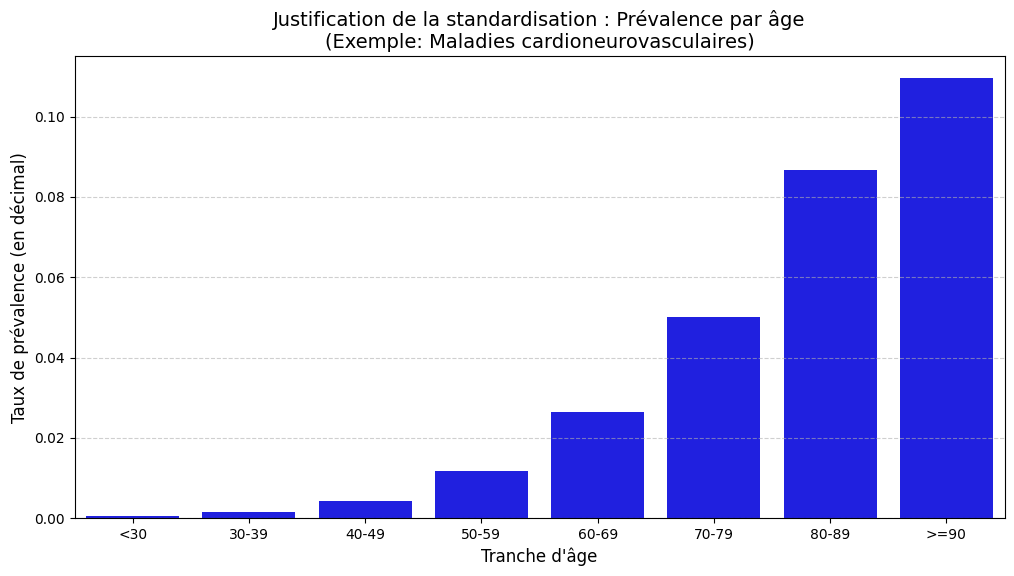

In [28]:

df_age_bis = df[(df['type'] == 'prevalence') & 
            (df['varGroupage'] == 'classeAge10') & 
            (df['varPartition'].isna()) &
            (df['catLib'] == 'Maladies cardioneurovasculaires')].copy()

ordre_age = ['<30', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '>=90']

df_age_bis['valGroupage'] = pd.Categorical(df_age_bis['valGroupage'], categories=ordre_age, ordered=True)

df_age_bis = df_age_bis.sort_values('valGroupage')

plt.figure(figsize=(12, 6))

sns.barplot(data=df_age_bis, x='valGroupage', y='txNonStand', color="blue", order=ordre_age, errorbar=None)

plt.title("Justification de la standardisation : Prévalence par âge\n(Exemple: Maladies cardioneurovasculaires)", fontsize=14)
plt.xlabel("Tranche d'âge", fontsize=12)
plt.ylabel("Taux de prévalence (en décimal)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)


plt.show()

On remarque directement que comme prévu, l'âge est un facteur déterminent dans cette étude. On remarque à l'aide de ce graphuique que le taux de prévalence explose avec l'âge. Afin de mener une étude sur les critères sociaux et non sur l'âge nous allons essayer d'effacer ce facteur. 
Pour cela la base de données dispose de données stadardisé par rapport à l'âge, voyons à quoi cela ressemble et si elle efface bien l'effet de l'âge.

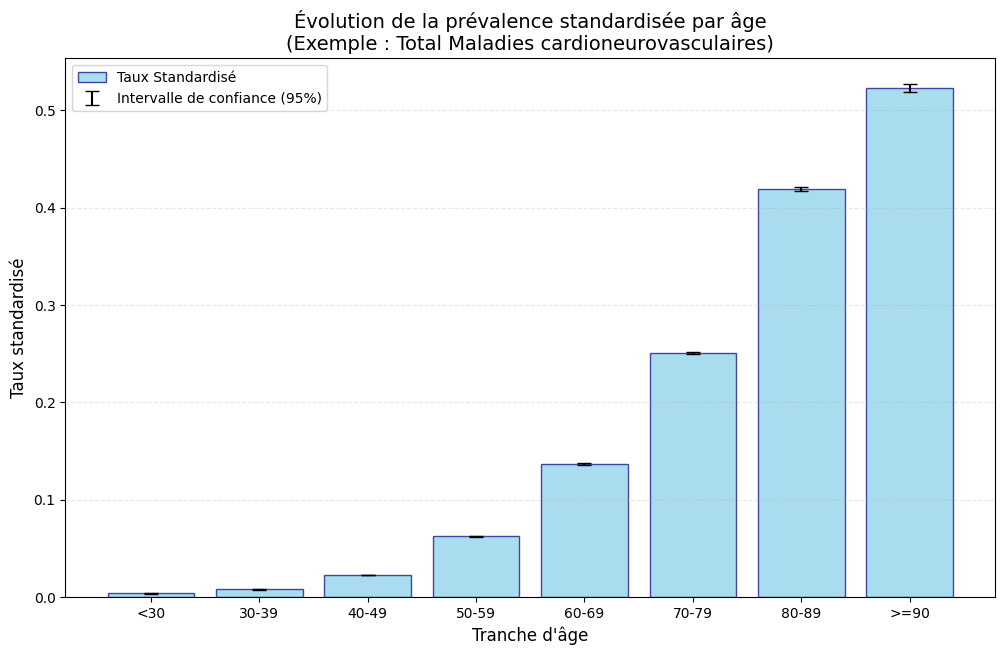

In [29]:

df_age_bis = df[
    (df['type'] == 'prevalence') & 
    (df['varGroupage'] == 'classeAge10') & 
    (df['varPartition'].isna()) &
    (df['varTauxLib'] == 'Maladies cardioneurovasculaires') # On prend le TOTAL uniquement
].copy()

df_age_bis = df_age_bis.dropna(subset=['valGroupage', 'txStandDir'])

ordre_age = ['<30', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '>=90']
df_age_bis['valGroupage'] = pd.Categorical(df_age_bis['valGroupage'], categories=ordre_age, ordered=True)
df_age_bis = df_age_bis.sort_values('valGroupage')

erreur_inf = df_age_bis['txStandDir'] - df_age_bis['txStandDirModBB']
erreur_sup = df_age_bis['txStandDirModBH'] - df_age_bis['txStandDir']
erreurs = [erreur_inf, erreur_sup]

plt.figure(figsize=(12, 7))

plt.bar(df_age_bis['valGroupage'].astype(str), df_age_bis['txStandDir'], 
        color='skyblue', edgecolor='navy', alpha=0.7, label='Taux Standardisé')

plt.errorbar(x=df_age_bis['valGroupage'].astype(str), y=df_age_bis['txStandDir'], 
             yerr=erreurs, fmt='none', ecolor='black', capsize=5, label='Intervalle de confiance (95%)')

plt.title("Évolution de la prévalence standardisée par âge\n(Exemple : Total Maladies cardioneurovasculaires)", fontsize=14)
plt.ylabel("Taux standardisé", fontsize=12)
plt.xlabel("Tranche d'âge", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend()

plt.show()



#### 5.1.2 Inégalités d'incidence par grandes catégories (Modestes vs Aisés)

Ce bloc calcule le ratio d'incidence entre les 10 % les plus modestes (Décile 1) et les 10 % les plus aisés (Décile 10).

In [30]:
mask_inc = (df['I_cat'] == 1) & (df['varPartition'].isna()) & \
           (df['varGroupage'] == 'FISC_NIVVIEM_E2015_S_moy_10') & \
           (df['type'] == 'incidence')

df_inc = df[mask_inc].copy()
# Conversion de la colonne des déciles en numérique
df_inc['valGroupage'] = pd.to_numeric(df_inc['valGroupage'], errors='coerce')

# Calcul du ratio D1 / D10
pivot_inc = df_inc.pivot_table(index='catLib', columns='valGroupage', values='txStandDir')
pivot_inc['Ratio_D1_D10'] = pivot_inc[1] / pivot_inc[10]

print("Inégalités d'incidence : Ratio Modestes (D1) / Aisés (D10)")
display(pivot_inc[['Ratio_D1_D10']].sort_values(by='Ratio_D1_D10', ascending=False))

Inégalités d'incidence : Ratio Modestes (D1) / Aisés (D10)


valGroupage,Ratio_D1_D10
catLib,
Diabète,2.786879
Insuffisance rénale chronique terminale,2.760562
Maladies du foie ou du pancréas,2.196438
Maladies psychiatriques,1.954073
Maladies respiratoires chroniques,1.575937
Maladies neurologiques ou dégénératives,1.494638
Maladies cardioneurovasculaires,1.357041
Maladies inflammatoires ou rares ou VIH ou SIDA,1.151304
Traitements du risque vasculaire,1.096190


#### 5.1.3 Évolution du ratio d'incidence selon le décile de niveau de vie

Ce bloc crée des graphiques en ligne (un par catégorie de maladie) montrant l'évolution du taux par rapport au 10ème décile.

/tmp/ipykernel_20379/3105459798.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_inc_ratio = df_inc.groupby('catLib', group_keys=False).apply(calc_ratio_d10)


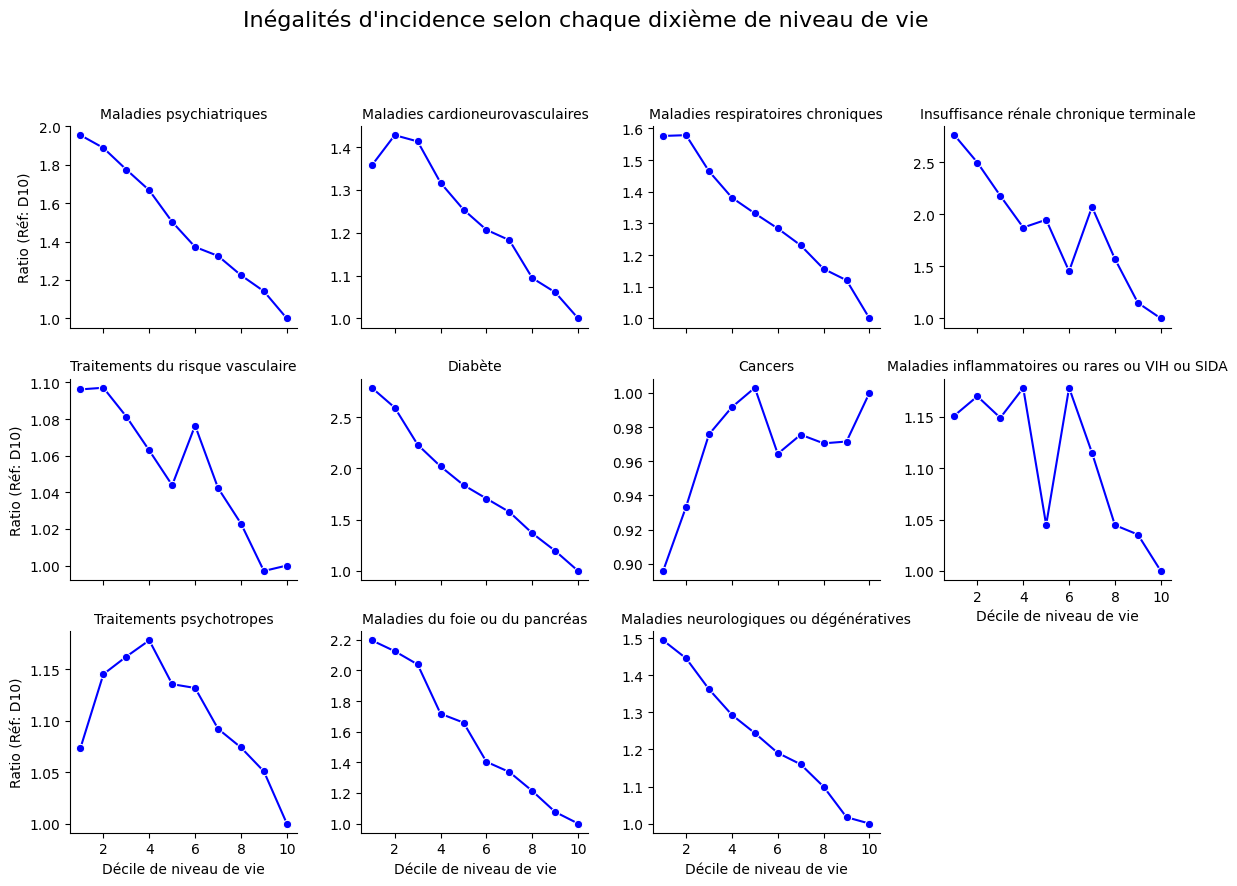

In [50]:
from fonctions import calc_ratio_d10

df_inc_ratio = df_inc.groupby('catLib', group_keys=False).apply(calc_ratio_d10)

# Visualisation 
g = sns.FacetGrid(df_inc_ratio, col="catLib", col_wrap=4, height=3, sharey=False)
g.map(sns.lineplot, "valGroupage", "ratio_to_D10", marker="o", color="blue")
g.set_axis_labels("Décile de niveau de vie", "Ratio (Réf: D10)")
g.set_titles(col_template="{col_name}")

plt.subplots_adjust(top=0.85)
g.fig.suptitle("Inégalités d'incidence selon chaque dixième de niveau de vie", fontsize=16)
plt.show()

Note de lecture : La valeur de référence est fixée à 1.0 pour le 10ème décile (les 10 % les plus aisés).
Les personnes appartenant au deuxième décile de niveau de vie ont un risque 15 % plus élevé d'avoir recours à des traitements psychotropes par rapport aux 10 % les plus aisés.

#### 5.1.4 Inégalités d'incidence selon le niveau de diplôme

Ce bloc de code a pour objectif d'isoler et de visualiser l'impact du niveau d'études sur l'apparition de nouvelles pathologies (l'incidence).

/tmp/ipykernel_20379/795251274.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_dip_ratio = df_dip.groupby('catLib', group_keys=False).apply(calc_ratio_dip)


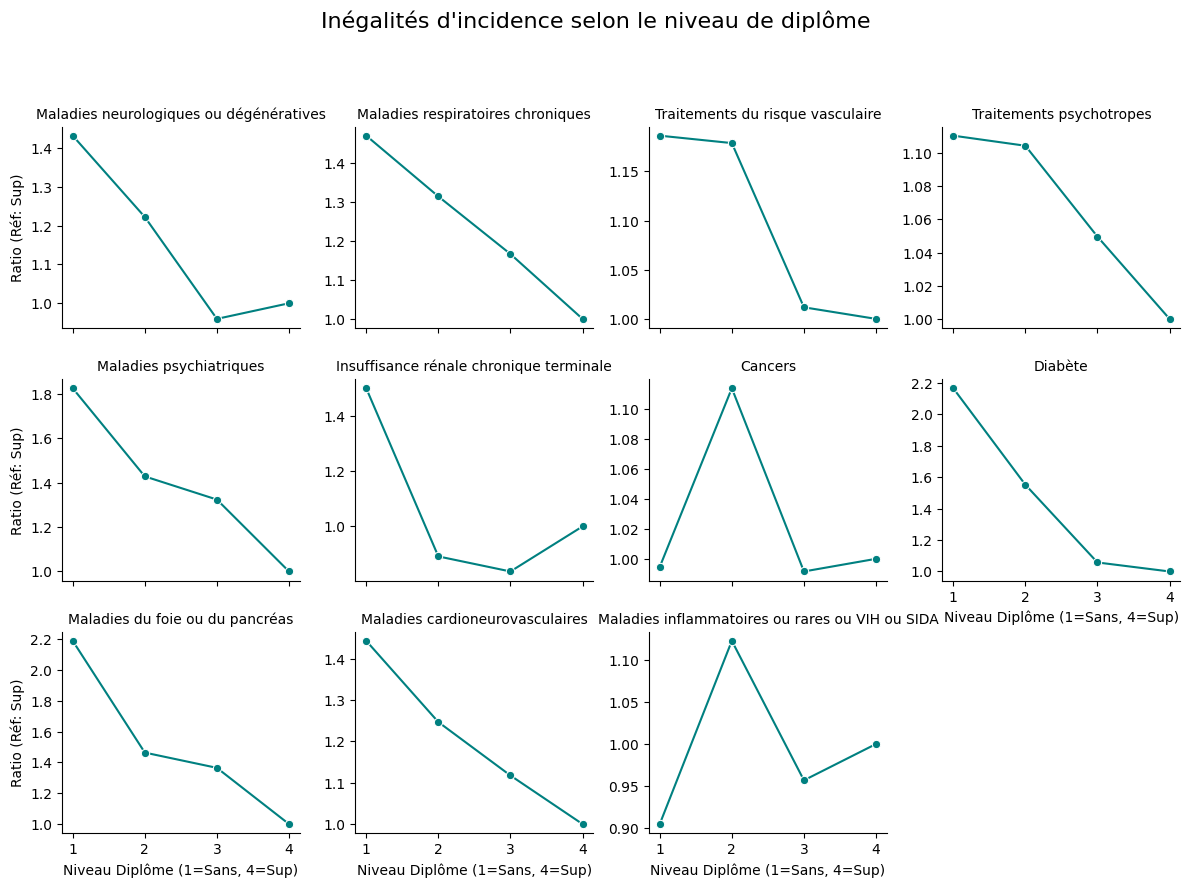

In [51]:
mask_dip = (df['I_cat'] == 1) & (df['varPartition'].isna()) & \
           (df['varGroupage'] == 'EAR_DIPLR_S') & \
           (df['type'] == 'incidence')

df_dip = df[mask_dip].copy()
df_dip['valGroupage'] = pd.to_numeric(df_dip['valGroupage'], errors='coerce')

df_dip_ratio = df_dip.groupby('catLib', group_keys=False).apply(calc_ratio_dip)

g_dip = sns.FacetGrid(df_dip_ratio, col="catLib", col_wrap=4, height=3, sharey=False)
g_dip.map(sns.lineplot, "valGroupage", "ratio_to_Sup", marker="o", color="teal")
g_dip.set_axis_labels("Niveau Diplôme (1=Sans, 4=Sup)", "Ratio (Réf: Sup)")
g_dip.set_titles(col_template="{col_name}")

plt.subplots_adjust(top=0.85)
g_dip.fig.suptitle("Inégalités d'incidence selon le niveau de diplôme", fontsize=16)
plt.show()

#### 5.1.5 Cartographie régionale des inégalités de prévalence

Cette série de cartes illustre l'intensité du gradient social de santé au sein de chaque région française pour différentes pathologies.

L'indicateur (Ratio D1/D10) : Il compare le taux de prévalence des 10 % les plus modestes à celui des 10 % les plus aisés.

/opt/python/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/opt/python/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/opt/python/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/opt/python/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/opt/python/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/opt/python/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)
/opt/python/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  re

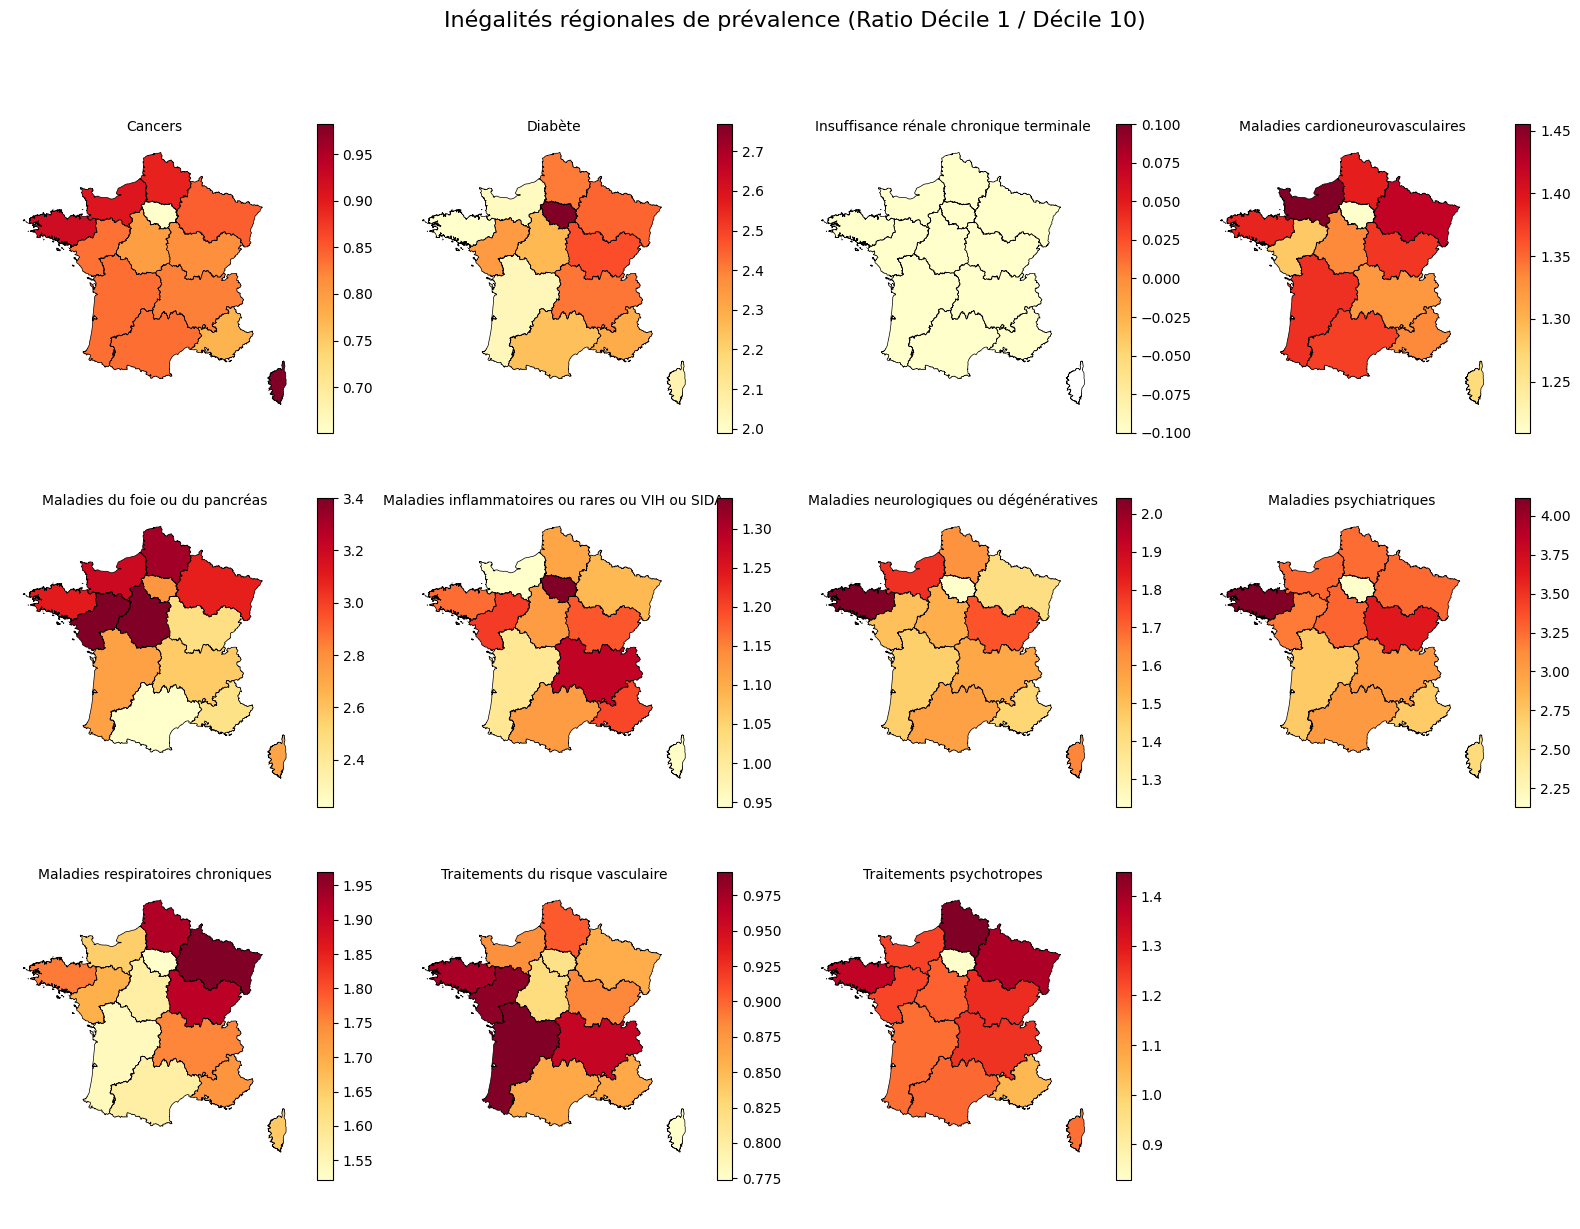

In [63]:
# Filtrage pour récupérer les données par région
mask_reg = (df['varGroupage'] == 'FISC_NIVVIEM_E2015_S_moy_10') & \
           (df['varPartition'] == 'FISC_REG_S') & \
           (df['type'] == 'prevalence') & \
           (df['I_cat'] == 1)

df_reg = df[mask_reg].copy()

# Pivot pour récupérer les valeurs des déciles 1 et 10 par région
pivot_reg = df_reg.pivot_table(index=['valPartition', 'catLib'], columns='valGroupage', values='txStandDir')
pivot_reg['ratio_D1_D10'] = pivot_reg['1'] / pivot_reg['10']
pivot_reg = pivot_reg.reset_index()
pivot_reg['valPartition'] = pivot_reg['valPartition'].astype(str)

# Téléchargement d'un fond de carte allégé des régions françaises (GeoJSON)
url_geojson = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/regions.geojson"
gdf_regions = gpd.read_file(url_geojson)

# Jointure spatiale (code région INSEE)
map_data = gdf_regions.merge(pivot_reg, left_on='code', right_on='valPartition', how='inner')

# Tracé des sous-graphiques géographiques
pathologies = map_data['catLib'].unique()
n_cols = 4
n_rows = (len(pathologies) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, patho in enumerate(pathologies):
    ax = axes[i]
    data_patho = map_data[map_data['catLib'] == patho]
    data_patho.plot(column='ratio_D1_D10', ax=ax, legend=True, 
                    cmap='YlOrRd', edgecolor='black', linewidth=0.5,
                    legend_kwds={'shrink': 0.8})
    ax.set_title(patho, fontsize=10)
    ax.axis('off')

# Masquer les axes vides
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Inégalités régionales de prévalence (Ratio Décile 1 / Décile 10)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Plus la teinte est sombre (rouge), plus l'inégalité sociale est marquée. À l'inverse, une teinte claire indique une pathologie qui frappe de manière plus uniforme les différentes classes sociales du territoire.

Ces cartes permettent d'identifier des zones de vulnérabilité où la précarité "pèse plus lourd" sur la santé. Par exemple, une région peut présenter une forte prévalence globale mais une faible inégalité (ratio proche de 1), suggérant un système de soin local qui parvient mieux à protéger les populations les plus fragiles.

### Carte bivariée

Si les graphiques linéaires révèlent l'existence d'un gradient social au niveau national, la carte bivariée permet d'observer comment ce phénomène s'incarne concrètement sur le territoire. Elle ne se contente pas d'afficher la localisation des malades ; elle croise deux dimensions
La carte bivariée croise deux variables : la prévalence au sein des plus modestes (D1) et l'intensité de l'inégalité (Ratio D1/D10).

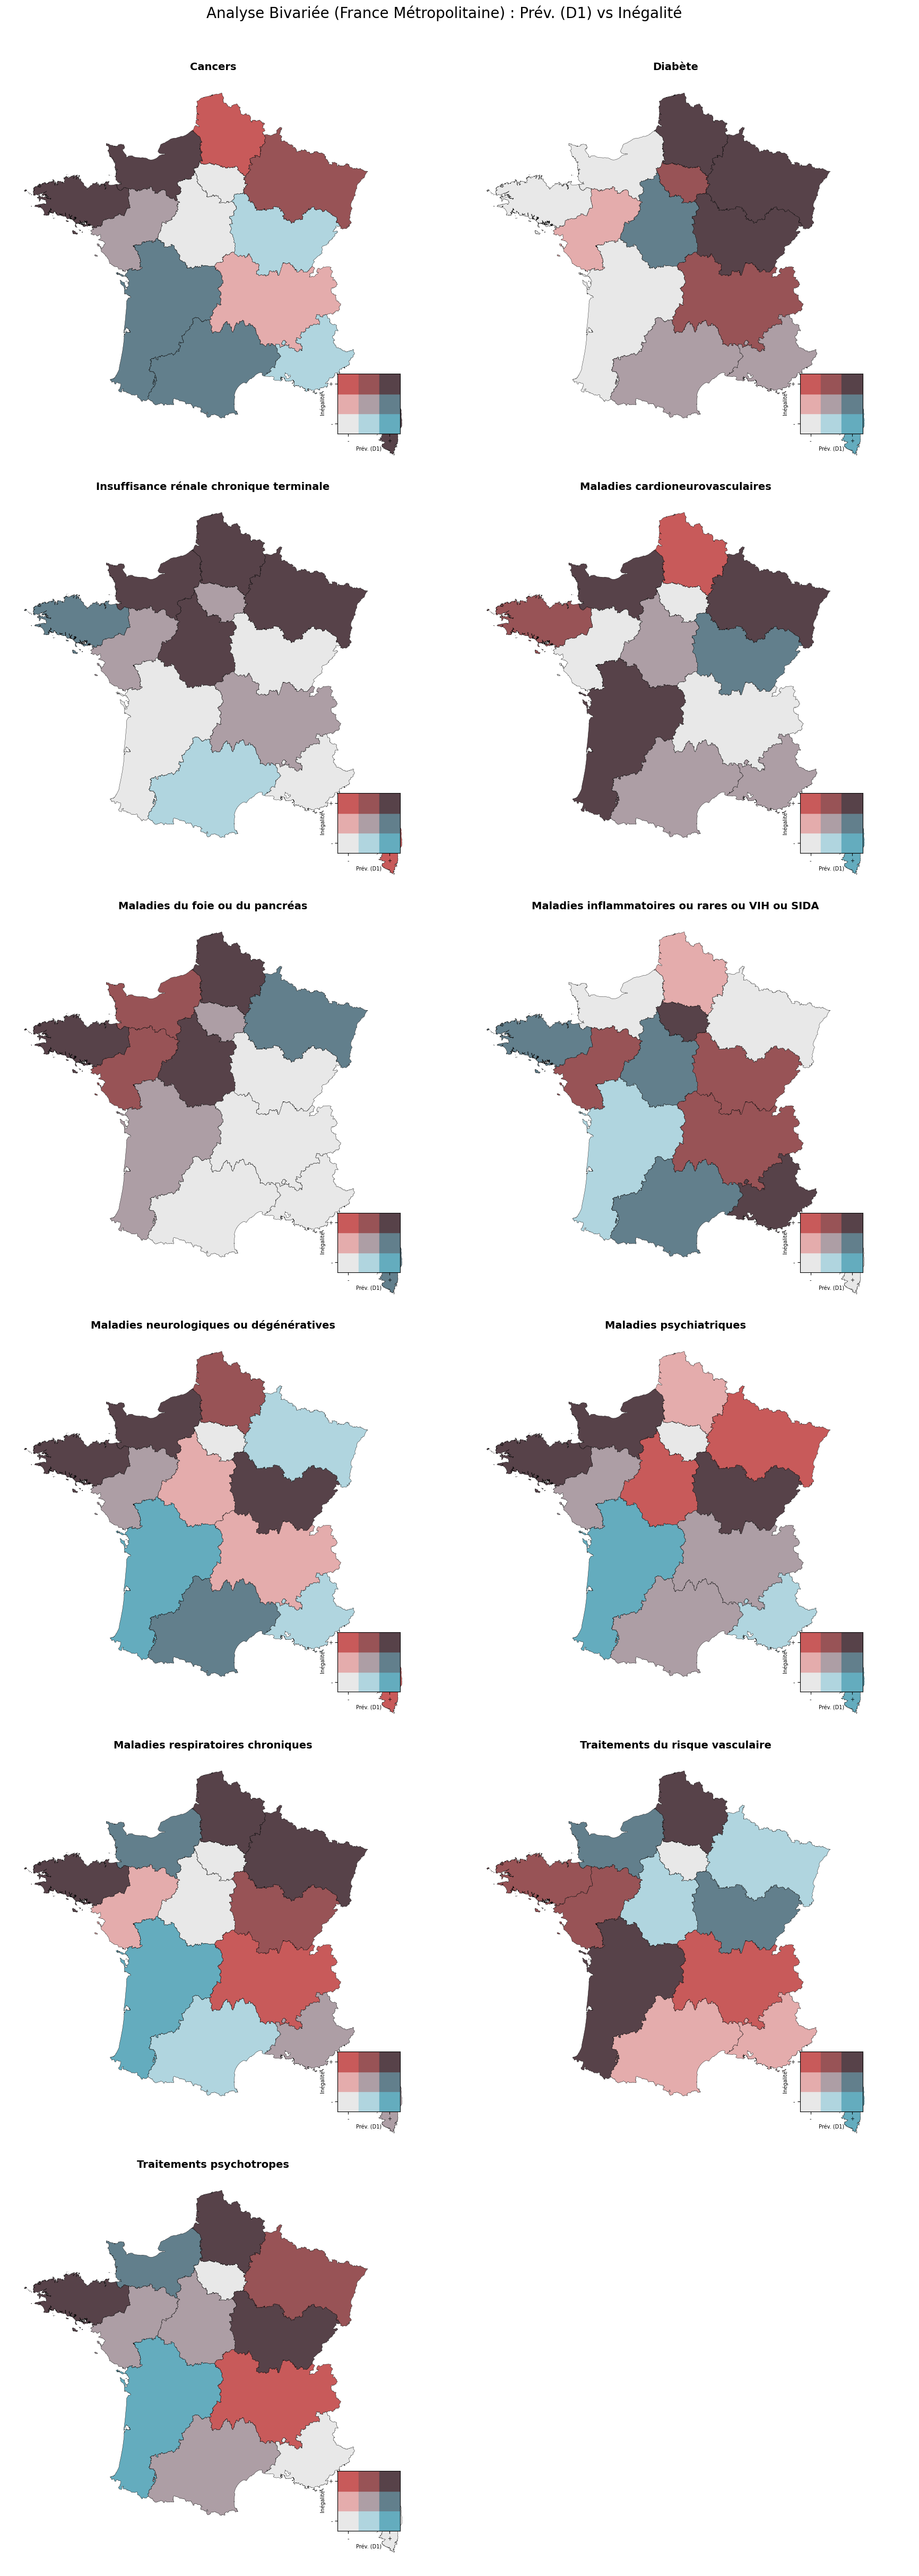

In [65]:

def plot_bivariate_metropole(geodf, var1, var2, label_x, label_y):
    # 1. Filtrage pour ne garder que la Métropole
    # On exclut les codes régions de l'Outre-mer (971, 972, 973, 974, 976)
    codes_drom = ['01', '02', '03', '04', '06', '971', '972', '973', '974', '976']
    geodf_metropole = geodf[~geodf['code'].isin(codes_drom)].copy()
    
    pathologies = geodf_metropole['catLib'].unique()
    
    # Paramètres de la grille
    n_cols = 2
    n_rows = (len(pathologies) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 8 * n_rows))
    axes = axes.flatten()
    
    bi_colors = [
        "#e8e8e8", "#b0d5df", "#64acbe", # y=0 (Bas)
        "#e4acac", "#ad9ea5", "#627f8c", # y=1 (Moyen)
        "#c85a5a", "#985356", "#574249"  # y=2 (Haut)
    ]
    cmap_bi = mcolors.ListedColormap(bi_colors)

    for i, patho in enumerate(pathologies):
        ax = axes[i]
        temp_df = geodf_metropole[geodf_metropole['catLib'] == patho].copy()
        
        if len(temp_df) < 3:
            ax.axis('off')
            continue

        # Calcul des terciles
        temp_df['x_cat'] = pd.qcut(temp_df[var1].rank(method='first'), 3, labels=[0, 1, 2])
        temp_df['y_cat'] = pd.qcut(temp_df[var2].rank(method='first'), 3, labels=[0, 1, 2])
        temp_df['bi_class'] = temp_df['x_cat'].astype(int) + temp_df['y_cat'].astype(int) * 3
        
        # Tracé de la carte
        temp_df.plot(column='bi_class', cmap=cmap_bi, ax=ax, edgecolor='black', linewidth=0.3)
        ax.set_title(patho, fontsize=14, fontweight='bold')
        ax.axis('off')
        
        # Légende miniature
        ax_leg = ax.inset_axes([0.80, 0.1, 0.15, 0.15]) 
        for y in range(3):
            for x in range(3):
                ax_leg.add_patch(plt.Rectangle((x, y), 1, 1, color=bi_colors[x + y*3]))
        
        ax_leg.set_xlim(0, 3); ax_leg.set_ylim(0, 3)
        ax_leg.set_xticks([0.5, 2.5]); ax_leg.set_yticks([0.5, 2.5])
        ax_leg.set_xticklabels(['-', '+'], fontsize=7)
        ax_leg.set_yticklabels(['-', '+'], fontsize=7)
        ax_leg.set_xlabel(label_x, fontsize=7)
        ax_leg.set_ylabel(label_y, fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"Analyse Bivariée (France Métropolitaine) : {label_x} vs {label_y}", fontsize=20, y=1.01)
    plt.tight_layout()
    plt.show()

# Utilisation
# Assure-toi que map_data contient une colonne 'code' pour les régions
plot_bivariate_metropole(
    map_data, 
    '1',                # Prévalence D1
    'ratio_D1_D10',     # Inégalité
    "Prév. (D1)", 
    "Inégalité"
)

## 6. Modélisation

### 6.1 Clustering des pathologies selon leur profil d'inégalité sociale

L'objectif est de regrouper les maladies chroniques selon la forme de leur gradient social : certaines touchent davantage les plus modestes, d'autres les plus aisés, d'autres encore ne présentent pas de gradient marqué.

On construit pour cela une matrice où chaque ligne est une maladie et chaque colonne est un décile de revenu. Les valeurs sont les taux de prévalence standardisés.

On construit la matrice.

In [ ]:
# On filtre sur la ventilation par décile de revenu, en prévalence uniquement,
# sans partition (vue nationale)
df_deciles = df[
    (df['varGroupage'] == 'FISC_NIVVIEM_E2015_S_moy_10') &
    (df['type'] == 'prevalence') &
    (df['varPartition'].isna())
][['varTauxLib', 'valGroupage', 'txStandDir']].dropna()

# Pivot : 1 ligne par maladie, 1 colonne par décile
matrice = df_deciles.pivot_table(
    index='varTauxLib',
    columns='valGroupage',
    values='txStandDir'
)

# Suppression des maladies avec des valeurs manquantes
matrice = matrice.dropna()

print(f"Matrice : {matrice.shape[0]} maladies × {matrice.shape[1]} déciles")
matrice.head()


Matrice : 52 maladies × 10 déciles


valGroupage,1,10,2,3,4,5,6,7,8,9
varTauxLib,,,,,,,,,,
Accident vasculaire cérébral aigu,0.002120,0.001495,0.002157,0.002175,0.001965,0.001866,0.001776,0.001741,0.001634,0.001629
Artériopathie oblitérante du membre inférieur,0.012508,0.006624,0.013862,0.013435,0.012744,0.011775,0.011347,0.010691,0.009511,0.008464
Autres affections cardiovasculaires,0.006074,0.003976,0.006822,0.007187,0.006779,0.006425,0.005954,0.005550,0.005170,0.004567
Autres affections neurologiques,0.003313,0.001853,0.003286,0.003087,0.002702,0.002395,0.002316,0.002145,0.002018,0.001853
Autres maladies inflammatoires chroniques,0.002945,0.002616,0.003326,0.003212,0.003404,0.003237,0.003124,0.002967,0.002874,0.003019


On normalise car sans elle, les maladies très prévalentes (comme le diabète) domineraient le clustering juste par leur ordre de grandeur, indépendamment de la forme de leur gradient.

In [36]:
scaler = StandardScaler()
matrice_scaled = scaler.fit_transform(matrice)

#### Choix du nombre de clusters

On utilise deux méthodes complémentaires pour choisir le nombre de clusters :
- La **méthode du coude** (inertie en fonction de k)
- Le **score de silhouette** (qualité de la séparation des clusters)

##### Méthode du coude

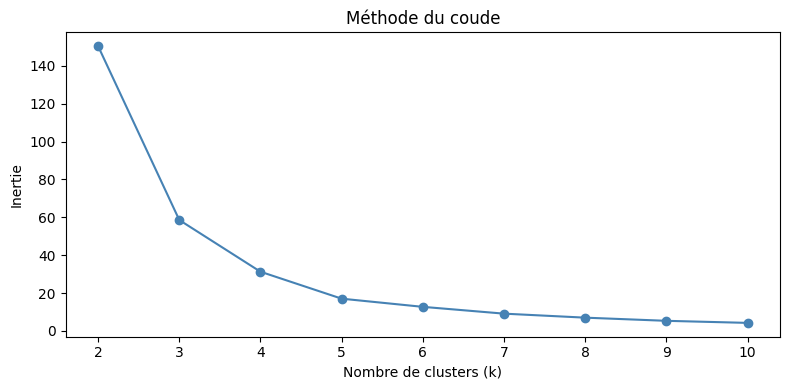

In [37]:
inerties = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(matrice_scaled)
    inerties.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inerties, marker='o', color='steelblue')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.tight_layout()
plt.show()

##### Score de silhouette

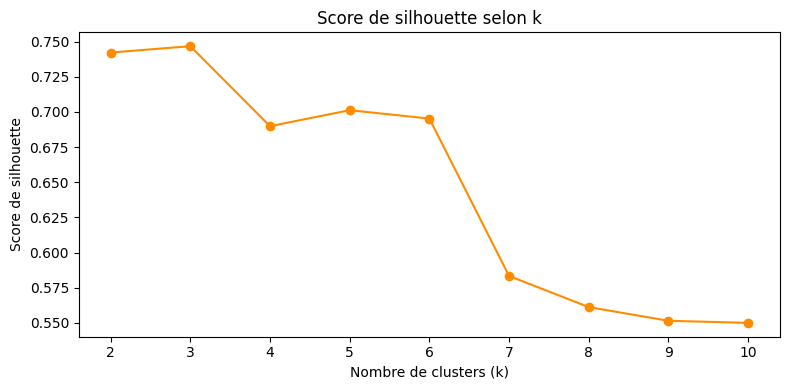

In [38]:
silhouettes = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans.fit_predict(matrice_scaled)
    silhouettes.append(silhouette_score(matrice_scaled, labels_k))

plt.figure(figsize=(8, 4))
plt.plot(K, silhouettes, marker='o', color='darkorange')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Score de silhouette")
plt.title("Score de silhouette selon k")
plt.tight_layout()
plt.show()

#### Modèle final

In [39]:
# À ajuster selon les graphiques précédents
K_FINAL = 4

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
matrice['cluster'] = kmeans_final.fit_predict(matrice_scaled)

print(f"Répartition des maladies par cluster :")
print(matrice['cluster'].value_counts().sort_index())

Répartition des maladies par cluster :
cluster
0     7
1     2
2     8
3    35
Name: count, dtype: int64


#### Interprétation des clusters

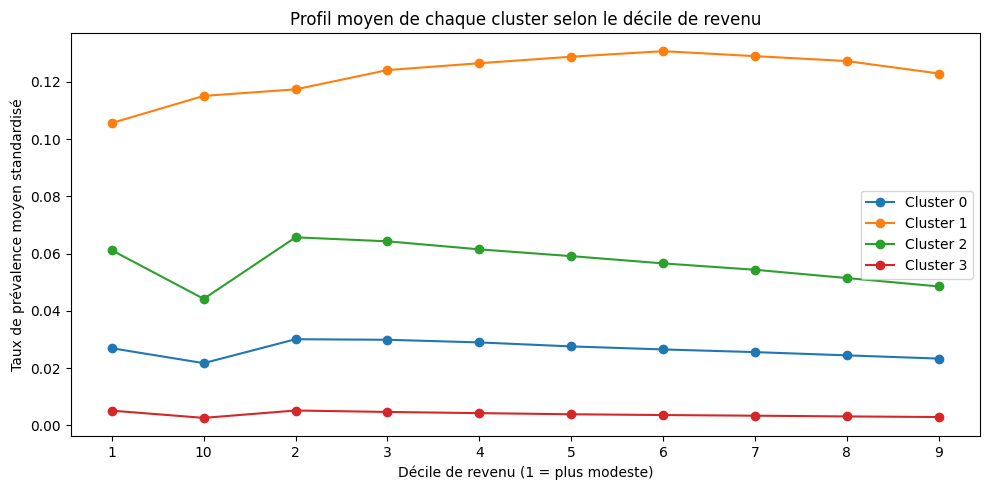

In [40]:
# Profil moyen de chaque cluster (taux par décile)
profils = matrice.groupby('cluster').mean()

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))

for cluster_id in profils.index:
    ax.plot(
        profils.columns.astype(str),
        profils.loc[cluster_id],
        marker='o',
        label=f"Cluster {cluster_id}"
    )

ax.set_xlabel("Décile de revenu (1 = plus modeste)")
ax.set_ylabel("Taux de prévalence moyen standardisé")
ax.set_title("Profil moyen de chaque cluster selon le décile de revenu")
ax.legend()
plt.tight_layout()
plt.show()

In [41]:
for c in sorted(matrice['cluster'].unique()):
    maladies = matrice[matrice['cluster'] == c].index.tolist()
    print(f"\nCluster {c} ({len(maladies)} maladies) :")
    for m in maladies:
        print(f"  - {m}")


Cluster 0 (7 maladies) :
  - Maladie coronaire chronique
  - Maladies inflammatoires ou rares ou VIH ou SIDA
  - Maladies neurologiques ou dégénératives
  - Traitements antidépresseurs ou régulateurs de l'humeur
  - Traitements hypnotiques
  - Troubles du rythme ou de la conduction cardiaque
  - Troubles névrotiques et de l’humeur

Cluster 1 (2 maladies) :
  - Traitements antihypertenseurs
  - Traitements du risque vasculaire

Cluster 2 (8 maladies) :
  - Cancers
  - Diabète
  - Maladies cardioneurovasculaires
  - Maladies psychiatriques
  - Maladies respiratoires chroniques
  - Traitements anxiolytiques
  - Traitements hypolipémiants
  - Traitements psychotropes

Cluster 3 (35 maladies) :
  - Accident vasculaire cérébral aigu
  - Artériopathie oblitérante du membre inférieur
  - Autres affections cardiovasculaires
  - Autres affections neurologiques
  - Autres maladies inflammatoires chroniques
  - Autres troubles psychiatriques
  - Dialyse chronique
  - Déficience mentale
  - Démenc

### 6.2 Régression : déterminants socio-économiques du taux de prévalence

L'objectif est d'identifier quels indicateurs socio-économiques régionaux (taux de pauvreté, revenu médian...) sont les plus associés au taux de prévalence des maladies chroniques.

On travaille ici à l'échelle régionale : chaque observation est une combinaison (maladie × région).

Point de vigilance : les résultats décrivent des tendances agrégées au niveau régional et ne permettent pas de conclusions au niveau individuel.

#### Construction du dataset de régression

In [67]:
# Taux de prévalence par région et par maladie (vue nationale, sans partition)
df_reg = df[
    (df['varGroupage'] == 'FISC_REG_S') &
    (df['type'] == 'prevalence') &
    (df['varPartition'].isna())
][['varTauxLib', 'valGroupage', 'txStandDir']].dropna()

df_reg = df_reg.rename(columns={'valGroupage': 'code_region'})

# Jointure avec les indicateurs INSEE
df_model = df_reg.merge(df_insee, left_on='code_region', right_on='insee', how='inner')

print(f"Dataset de régression : {df_model.shape}")
df_model.head()

Dataset de régression : (0, 40)


,varTauxLib,code_region,txStandDir,Geo Point,Geo Shape,gid,geom_err,ident,insee,val_approchee,...,nb_ind_11_17,nb_ind_18_24,nb_ind_25_39,nb_ind_40_54,nb_ind_55_64,nb_ind_65_79,nb_ind_80p,nb_ind_nc,cdate,mdate


In [ ]:
FEATURES = ['taux_pauvrete', 'revenu_median']
CIBLE = 'txStandDir'

df_model_clean = df_model[FEATURES + [CIBLE]].dropna()

X = df_model_clean[FEATURES]
y = df_model_clean[CIBLE]

print(f"Observations disponibles : {len(X)}")
print(f"Features : {FEATURES}")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2  = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²   : {r2:.3f}")
print(f"RMSE : {rmse:.4f}")

In [ ]:
coefs = pd.DataFrame({
    'variable': FEATURES,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("Coefficients du modèle :")
print(coefs)

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', label='Prédiction parfaite')
plt.xlabel("Taux réel")
plt.ylabel("Taux prédit")
plt.title("Valeurs réelles vs prédites")
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion